# SBTE Phase 2 Smoke: Inference-Time Latent Guidance

**Shortest possible test** of *training-free* attention shaping. At each anchor-window denoising step, take a few gradient steps on `x_t` to reduce the per-slot KL between captured cross-attention and the per-character target maps, then take the scheduler step. No LoRA, no training.

## What we're shipping
- One seed, one guidance scale, one window. No sweeps.
- Reuse Phase 1's letterspaced prompt + per-slot targets + capture processors verbatim.
- Apples-to-apples comparison: baseline inference vs guided inference, both **CFG-free** (so the only variable is whether we run the guidance loop). Image quality will be muted in both. We're measuring whether attention can be reshaped, not whether the image is pretty.
- Sanity cell first: at one timestep, does KL actually drop within the refinement loop? If not, nothing else matters and we stop.

## Pass / fail
- **Pass:** sanity KL drops monotonically across refinement iters at one timestep, AND the guided final-aggregate attention visibly resembles GARDEN-shape vs. the baseline's band, AND mean per-slot KL at the end of the anchor window is meaningfully lower than baseline.
- **Fail:** gradient on `x_t` doesn't move the captured attention, OR moves it but produces NaN/instability.
- **Mixed (still write-up-able):** KL drops in some slots but not others; image becomes garbled. That's a real partial result and worth reporting.

Logs to `/content/drive/MyDrive/mmai_sbte_phase2/`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
LOG_DIR = '/content/drive/MyDrive/mmai_sbte_phase2'
os.makedirs(LOG_DIR, exist_ok=True)
print(f'Logs -> {LOG_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Logs -> /content/drive/MyDrive/mmai_sbte_phase2


In [ ]:
%pip install -q --upgrade diffusers==0.31.0 transformers==4.46.0 accelerate==1.0.0 peft==0.13.0 safetensors scipy matplotlib
%pip install -q --force-reinstall --no-deps pillow==10.4.0

# After this cell, do Runtime > Restart session, then re-run from this cell.

In [ ]:
import json, time
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageDraw, ImageFont
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

from diffusers import StableDiffusionXLPipeline, DDIMScheduler
from diffusers.models.attention_processor import Attention

device = 'cuda'
dtype = torch.float16
print(f'GPU: {torch.cuda.get_device_name(0)}  |  dtype: {dtype}')

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

GPU: Tesla T4  |  dtype: torch.float16


In [ ]:
CONFIG = {
    'target_string': 'GARDEN',
    'prompt': 'a sign on a blank white background that says G A R D E N',

    'image_size': 1024,
    'latent_size': 128,
    'attn_resolution': 64,
    'bbox_normalized': [0.10, 0.30, 0.90, 0.70],

    'target_sigma': 1.0,
    'target_floor': 1e-4,

    'inference_steps': 30,
    'anchor_window': [700, 900],

    'guidance_scale': 5,        # latent step size
    'n_refinement_iters': 3,      # gradient steps per anchor timestep
    'seed': 42,
}

with open(f'{LOG_DIR}/config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(json.dumps(CONFIG, indent=2))

{
  "target_string": "GARDEN",
  "prompt": "a sign on a blank white background that says G A R D E N",
  "image_size": 1024,
  "latent_size": 128,
  "attn_resolution": 64,
  "bbox_normalized": [
    0.1,
    0.3,
    0.9,
    0.7
  ],
  "target_sigma": 1.0,
  "target_floor": 0.0001,
  "inference_steps": 30,
  "anchor_window": [
    700,
    900
  ],
  "guidance_scale": 5,
  "n_refinement_iters": 3,
  "seed": 42
}


## Load SDXL (no LoRA, weights frozen)

In [ ]:
pipe = StableDiffusionXLPipeline.from_pretrained(
    'stabilityai/stable-diffusion-xl-base-1.0',
    torch_dtype=dtype, use_safetensors=True,
).to(device)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

pipe.vae.requires_grad_(False); pipe.vae.eval()
pipe.text_encoder.requires_grad_(False); pipe.text_encoder.eval()
pipe.text_encoder_2.requires_grad_(False); pipe.text_encoder_2.eval()
pipe.unet.requires_grad_(False); pipe.unet.eval()

print('SDXL loaded, all params frozen, no LoRA attached.')

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Build per-slot targets (same as Phase 1)

N=6 normalized 64×64 maps, one per character of GARDEN.

In [ ]:
FONT_CANDIDATES = [
    '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
    '/usr/share/fonts/dejavu/DejaVuSans-Bold.ttf',
    'DejaVuSans-Bold.ttf',
]

def find_font(size):
    size = max(1, int(size))
    for path in FONT_CANDIDATES:
        try:
            return ImageFont.truetype(path, size)
        except (OSError, IOError):
            continue
    return ImageFont.load_default()

def fit_font(text, box_w, box_h):
    img = Image.new('L', (1, 1), 0)
    draw = ImageDraw.Draw(img)
    for sz in range(max(box_h, 8), 0, -1):
        f = find_font(sz)
        bb = draw.textbbox((0, 0), text, font=f)
        if bb[2]-bb[0] <= box_w and bb[3]-bb[1] <= box_h:
            return f
    return find_font(1)

def build_per_slot_targets(text, attn_res, bbox_norm, sigma, floor):
    H = W = attn_res
    bx1, by1, bx2, by2 = (int(bbox_norm[0]*W), int(bbox_norm[1]*H),
                          int(bbox_norm[2]*W), int(bbox_norm[3]*H))
    box_w, box_h = max(1, bx2-bx1), max(1, by2-by1)
    font = fit_font(text, box_w, box_h)

    img_full = Image.new('L', (W, H), 0)
    draw = ImageDraw.Draw(img_full)
    bb = draw.textbbox((0, 0), text, font=font)
    tw, th = bb[2]-bb[0], bb[3]-bb[1]
    cx, cy = (bx1+bx2)/2, (by1+by2)/2
    x0 = cx - tw/2 - bb[0]
    y0 = cy - th/2 - bb[1]

    targets = []
    for i, ch in enumerate(text):
        prefix = text[:i]
        x_offset = draw.textlength(prefix, font=font) if prefix else 0
        img_char = Image.new('L', (W, H), 0)
        ImageDraw.Draw(img_char).text((x0 + x_offset, y0), ch, fill=255, font=font)
        m = np.array(img_char, dtype=np.float32) / 255.0
        m = gaussian_filter(m, sigma=sigma) if sigma > 0 else m
        m = m + floor
        m = m / m.sum()
        targets.append(m)
    return torch.from_numpy(np.stack(targets)).float()

A_star_slots = build_per_slot_targets(
    CONFIG['target_string'], CONFIG['attn_resolution'],
    CONFIG['bbox_normalized'], CONFIG['target_sigma'], CONFIG['target_floor'],
).to(device)
N_SLOTS = len(CONFIG['target_string'])
print(f'A_star_slots: {tuple(A_star_slots.shape)}, N_SLOTS={N_SLOTS}')
print(f'Per-slot sums (should each be 1.0): {[round(A_star_slots[i].sum().item(), 4) for i in range(N_SLOTS)]}')

A_star_slots: (6, 64, 64), N_SLOTS=6
Per-slot sums (should each be 1.0): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## Attention capture + token positions (same as Phase 1)

In [ ]:
ATTN_STORE = {}

class CaptureAttnProcessor:
    def __init__(self, name, capture_resolution):
        self.name = name
        self.capture_resolution = capture_resolution
        self.enabled = False

    def __call__(self, attn, hidden_states, encoder_hidden_states=None,
                 attention_mask=None, **kwargs):
        residual = hidden_states
        input_ndim = hidden_states.ndim
        if input_ndim == 4:
            b, c, h, w = hidden_states.shape
            hidden_states = hidden_states.view(b, c, h*w).transpose(1, 2)

        is_cross = encoder_hidden_states is not None
        if encoder_hidden_states is None:
            encoder_hidden_states = hidden_states

        bsz = hidden_states.shape[0]
        if attention_mask is not None:
            attention_mask = attn.prepare_attention_mask(
                attention_mask, encoder_hidden_states.shape[1], bsz)

        q = attn.to_q(hidden_states)
        k = attn.to_k(encoder_hidden_states)
        v = attn.to_v(encoder_hidden_states)
        q = attn.head_to_batch_dim(q)
        k = attn.head_to_batch_dim(k)
        v = attn.head_to_batch_dim(v)

        attn_probs = attn.get_attention_scores(q, k, attention_mask)

        if is_cross and self.enabled:
            spatial = attn_probs.shape[1]
            res = int(spatial ** 0.5)
            if res == self.capture_resolution and res * res == spatial:
                ATTN_STORE[self.name] = attn_probs

        out = torch.bmm(attn_probs, v)
        out = attn.batch_to_head_dim(out)
        out = attn.to_out[0](out)
        out = attn.to_out[1](out)

        if input_ndim == 4:
            out = out.transpose(-1, -2).reshape(b, c, h, w)
        if attn.residual_connection:
            out = out + residual
        return out / attn.rescale_output_factor

def install_processors(unet, capture_resolution):
    procs = {}
    for name, module in unet.named_modules():
        if isinstance(module, Attention) and 'attn2' in name:
            p = CaptureAttnProcessor(name, capture_resolution)
            module.set_processor(p)
            procs[name] = p
    return procs

def set_capture(procs, enabled):
    for p in procs.values():
        p.enabled = enabled

def clear_store():
    ATTN_STORE.clear()

CAPTURE_PROCS = install_processors(pipe.unet, CONFIG['attn_resolution'])
print(f'Installed {len(CAPTURE_PROCS)} cross-attention capture processors')

Installed 70 cross-attention capture processors


In [ ]:
@torch.no_grad()
def encode_prompt(pipe, prompt):
    ids_1 = pipe.tokenizer(prompt, padding='max_length', max_length=77,
                           truncation=True, return_tensors='pt').input_ids.to(device)
    ids_2 = pipe.tokenizer_2(prompt, padding='max_length', max_length=77,
                             truncation=True, return_tensors='pt').input_ids.to(device)
    out_1 = pipe.text_encoder(ids_1, output_hidden_states=True)
    out_2 = pipe.text_encoder_2(ids_2, output_hidden_states=True)
    return torch.cat([out_1.hidden_states[-2], out_2.hidden_states[-2]], dim=-1), out_2[0]

def find_letterspaced_token_indices(tokenizer, prompt, target_word):
    ids = tokenizer(prompt, padding='max_length', max_length=77,
                    truncation=True, return_tensors='pt').input_ids[0].tolist()
    decoded = [tokenizer.decode([i]).strip().upper() for i in ids]
    target = list(target_word.upper())
    for start in range(len(decoded) - len(target) + 1):
        if decoded[start:start+len(target)] == target:
            return list(range(start, start+len(target))), decoded[start:start+len(target)]
    return None, None

prompt_embeds, pooled = encode_prompt(pipe, CONFIG['prompt'])

tok_idx_1, decoded_1 = find_letterspaced_token_indices(
    pipe.tokenizer, CONFIG['prompt'], CONFIG['target_string'])
tok_idx_2, _ = find_letterspaced_token_indices(
    pipe.tokenizer_2, CONFIG['prompt'], CONFIG['target_string'])

assert tok_idx_1 is not None and tok_idx_2 is not None
TOKEN_INDICES_PER_SLOT = tok_idx_1
assert len(TOKEN_INDICES_PER_SLOT) == N_SLOTS
print(f'Token positions per slot: {TOKEN_INDICES_PER_SLOT} -> {decoded_1}')
print(f'prompt_embeds: {tuple(prompt_embeds.shape)}, pooled: {tuple(pooled.shape)}')

Token positions per slot: [10, 11, 12, 13, 14, 15] -> ['G', 'A', 'R', 'D', 'E', 'N']
prompt_embeds: (1, 77, 2048), pooled: (1, 1280)


In [ ]:
def get_per_slot_attn(store, target_res, token_indices_per_slot):
    per_layer = []
    for name, attn_probs in store.items():
        spatial = attn_probs.shape[1]
        res = int(spatial ** 0.5)
        if res != target_res or res*res != spatial:
            continue
        slot_maps = []
        for tok_pos in token_indices_per_slot:
            col = attn_probs[:, :, tok_pos].mean(dim=0)  # mean over heads
            slot_maps.append(col)
        per_layer.append(torch.stack(slot_maps))
    if not per_layer:
        return None
    avg = torch.stack(per_layer).mean(dim=0)  # [N_slots, spatial]
    return avg.view(len(token_indices_per_slot), target_res, target_res)

def normalize_per_slot(maps, eps=1e-8):
    maps = maps + eps
    sums = maps.view(maps.shape[0], -1).sum(dim=1, keepdim=True).view(-1, 1, 1)
    return maps / sums

def per_slot_kl(target, model, eps=1e-8):
    p = target + eps
    q = model + eps
    kl_per_slot = (p * (p.log() - q.log())).view(p.shape[0], -1).sum(dim=1)
    return kl_per_slot.mean(), kl_per_slot

def make_time_ids(batch=1):
    return torch.tensor([[1024, 1024, 0, 0, 1024, 1024]],
                        dtype=dtype, device=device).repeat(batch, 1)
TIME_IDS = make_time_ids()

## Sanity check

One timestep in the anchor window. Run the refinement loop. Print KL after every iter. **If it doesn't drop, stop.**

In [ ]:
torch.manual_seed(CONFIG['seed'])
gen = torch.Generator(device=device).manual_seed(CONFIG['seed'])

pipe.scheduler.set_timesteps(CONFIG['inference_steps'])
ts = [int(t.item()) for t in pipe.scheduler.timesteps]
lo, hi = CONFIG['anchor_window']
anchor_ts = [t for t in ts if lo <= t <= hi]
print(f'DDIM timesteps ({len(ts)}): {ts}')
print(f'Anchor-window timesteps: {anchor_ts}')
assert len(anchor_ts) >= 1, f'No timesteps fall in {CONFIG["anchor_window"]} for {CONFIG["inference_steps"]} DDIM steps'

# Build a fresh latent at t = highest timestep, run unguided steps until we reach the
# first anchor timestep, then run the refinement loop there.
latents = torch.randn((1, 4, CONFIG['latent_size'], CONFIG['latent_size']),
                      generator=gen, device=device, dtype=dtype)

with torch.no_grad():
    for t in pipe.scheduler.timesteps:
        if int(t.item()) <= anchor_ts[0]:
            break
        clear_store()
        set_capture(CAPTURE_PROCS, False)
        noise_pred = pipe.unet(
            latents, t,
            encoder_hidden_states=prompt_embeds.to(dtype),
            added_cond_kwargs={'text_embeds': pooled.to(dtype), 'time_ids': TIME_IDS},
        ).sample
        latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

t_test = pipe.scheduler.timesteps[[int(x.item()) for x in pipe.scheduler.timesteps].index(anchor_ts[0])]
print(f'\nRunning sanity refinement at t = {int(t_test.item())}')

# Run 3 refinement iters and print KL after each
latent_pre = latents.clone()
kl_iters = []
for it in range(CONFIG['n_refinement_iters']):
    latents = latents.detach().requires_grad_(True)

    clear_store()
    set_capture(CAPTURE_PROCS, True)
    noise_pred = pipe.unet(
        latents, t_test,
        encoder_hidden_states=prompt_embeds.to(dtype),
        added_cond_kwargs={'text_embeds': pooled.to(dtype), 'time_ids': TIME_IDS},
    ).sample

    A_t = get_per_slot_attn(ATTN_STORE, CONFIG['attn_resolution'], TOKEN_INDICES_PER_SLOT)
    assert A_t is not None
    A_norm = normalize_per_slot(A_t.float())
    kl_loss, kl_per = per_slot_kl(A_star_slots, A_norm)
    kl_iters.append((kl_loss.item(), [x.item() for x in kl_per]))

    grad = torch.autograd.grad(kl_loss, latents)[0]
    grad_norm_pre_normalize = grad.float().norm().item()
    grad = grad / (grad.norm() + 1e-8)

    with torch.no_grad():
        latents = latents - CONFIG['guidance_scale'] * grad.to(dtype)

    print(f'  iter {it}: mean KL = {kl_iters[-1][0]:.4f}  |  raw |grad|_2 = {grad_norm_pre_normalize:.3e}  |  per-slot = {[round(x, 3) for x in kl_iters[-1][1]]}')

delta = kl_iters[0][0] - kl_iters[-1][0]
status = 'PASS' if delta > 0 and not np.isnan(kl_iters[-1][0]) else 'FAIL'
print(f'\n{status}: KL delta over {CONFIG["n_refinement_iters"]} iters = {delta:+.4f}')
set_capture(CAPTURE_PROCS, False); clear_store()

DDIM timesteps (30): [958, 925, 892, 859, 826, 793, 760, 727, 694, 661, 628, 595, 562, 529, 496, 463, 430, 397, 364, 331, 298, 265, 232, 199, 166, 133, 100, 67, 34, 1]
Anchor-window timesteps: [892, 859, 826, 793, 760, 727]

Running sanity refinement at t = 892
  iter 0: mean KL = 3.7730  |  raw |grad|_2 = 2.971e-03  |  per-slot = [3.678, 3.923, 3.798, 3.685, 3.822, 3.732]
  iter 1: mean KL = 3.7582  |  raw |grad|_2 = 2.241e-03  |  per-slot = [3.665, 3.904, 3.777, 3.673, 3.805, 3.724]
  iter 2: mean KL = 3.7459  |  raw |grad|_2 = 2.199e-03  |  per-slot = [3.651, 3.889, 3.764, 3.661, 3.794, 3.717]

PASS: KL delta over 3 iters = +0.0271


## Compare guided vs unguided

Both runs are CFG-free for apples-to-apples (only difference is whether we run the refinement loop at anchor timesteps).

In [ ]:
def denoising_loop(pipe, latents_init, prompt_embeds, pooled, time_ids,
                   capture_procs, token_indices, A_star_slots, attn_res, n_steps,
                   anchor_window, guidance_scale, n_refinement_iters,
                   guided=True):
    pipe.scheduler.set_timesteps(n_steps)
    latents = latents_init.clone()
    lo, hi = anchor_window
    trace = []

    for step_idx, t in enumerate(pipe.scheduler.timesteps):
        t_val = int(t.item())
        in_anchor = lo <= t_val <= hi

        if in_anchor and guided:
            kl_iters = []
            for it in range(n_refinement_iters):
                latents = latents.detach().requires_grad_(True)
                clear_store()
                set_capture(capture_procs, True)
                noise_pred = pipe.unet(
                    latents, t,
                    encoder_hidden_states=prompt_embeds,
                    added_cond_kwargs={'text_embeds': pooled, 'time_ids': time_ids},
                ).sample
                A_t = get_per_slot_attn(ATTN_STORE, attn_res, token_indices)
                A_norm = normalize_per_slot(A_t.float())
                kl_loss, _ = per_slot_kl(A_star_slots, A_norm)
                kl_iters.append(kl_loss.item())

                grad = torch.autograd.grad(kl_loss, latents)[0]
                grad = grad / (grad.norm() + 1e-8)
                with torch.no_grad():
                    latents = latents - guidance_scale * grad.to(latents.dtype)
            trace.append({'step': step_idx, 't': t_val, 'kl_iters': kl_iters,
                          'kl_pre': kl_iters[0], 'kl_post': kl_iters[-1]})
            # Final clean forward + scheduler step
            set_capture(capture_procs, False)
            with torch.no_grad():
                clear_store()
                noise_pred = pipe.unet(
                    latents, t,
                    encoder_hidden_states=prompt_embeds,
                    added_cond_kwargs={'text_embeds': pooled, 'time_ids': time_ids},
                ).sample
                latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

        else:
            # In-anchor but NOT guided: still capture KL for the trace (one forward, no grad).
            with torch.no_grad():
                if in_anchor:
                    clear_store()
                    set_capture(capture_procs, True)
                else:
                    set_capture(capture_procs, False)
                    clear_store()
                noise_pred = pipe.unet(
                    latents, t,
                    encoder_hidden_states=prompt_embeds,
                    added_cond_kwargs={'text_embeds': pooled, 'time_ids': time_ids},
                ).sample
                if in_anchor:
                    A_t = get_per_slot_attn(ATTN_STORE, attn_res, token_indices)
                    A_norm = normalize_per_slot(A_t.float())
                    kl_loss, _ = per_slot_kl(A_star_slots, A_norm)
                    trace.append({'step': step_idx, 't': t_val,
                                  'kl_iters': [kl_loss.item()],
                                  'kl_pre': kl_loss.item(),
                                  'kl_post': kl_loss.item()})
                set_capture(capture_procs, False)
                clear_store()
                latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

    return latents, trace

print('denoising_loop defined.')

denoising_loop defined.


In [ ]:
def run_and_decode(guided):
    gen = torch.Generator(device=device).manual_seed(CONFIG['seed'])
    latents_init = torch.randn((1, 4, CONFIG['latent_size'], CONFIG['latent_size']),
                                generator=gen, device=device, dtype=dtype)
    t0 = time.time()
    latents_final, trace = denoising_loop(
        pipe, latents_init,
        prompt_embeds.to(dtype), pooled.to(dtype), TIME_IDS,
        CAPTURE_PROCS, TOKEN_INDICES_PER_SLOT, A_star_slots,
        CONFIG['attn_resolution'], CONFIG['inference_steps'],
        CONFIG['anchor_window'], CONFIG['guidance_scale'],
        CONFIG['n_refinement_iters'],
        guided=guided,
    )
    elapsed = time.time() - t0

    # Capture final attention at the LAST anchor timestep already happened during the loop;
    # for visualization, also capture once at a low-t step so we can show the final attention.
    # Easiest: re-do one forward at the lowest timestep with capture on.
    set_capture(CAPTURE_PROCS, True); clear_store()
    with torch.no_grad():
        _ = pipe.unet(
            latents_final, pipe.scheduler.timesteps[-1],
            encoder_hidden_states=prompt_embeds.to(dtype),
            added_cond_kwargs={'text_embeds': pooled.to(dtype), 'time_ids': TIME_IDS},
        ).sample
    A_final = get_per_slot_attn(ATTN_STORE, CONFIG['attn_resolution'], TOKEN_INDICES_PER_SLOT)
    A_final = normalize_per_slot(A_final.float()).detach().cpu().numpy()
    set_capture(CAPTURE_PROCS, False); clear_store()

    # Decode to image
    with torch.no_grad():
        img_latents = latents_final / pipe.vae.config.scaling_factor
        img = pipe.vae.decode(img_latents.to(dtype)).sample
        img = ((img/2 + 0.5).clamp(0, 1)[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

    return {'image': img, 'A_final': A_final, 'trace': trace, 'elapsed_sec': elapsed}

print('Running unguided baseline...')
baseline = run_and_decode(guided=False)
print(f'  baseline: {baseline["elapsed_sec"]:.1f}s, {len(baseline["trace"])} anchor timesteps captured')
for row in baseline['trace']:
    print(f'    t={row["t"]:3d}  KL={row["kl_pre"]:.4f}')

Running unguided baseline...
  baseline: 14.0s, 6 anchor timesteps captured
    t=892  KL=3.7730
    t=859  KL=3.7749
    t=826  KL=3.7769
    t=793  KL=3.7791
    t=760  KL=3.7817
    t=727  KL=3.7843


/tmp/ipykernel_5815/3319315661.py:35: RuntimeWarning: invalid value encountered in cast
  img = ((img/2 + 0.5).clamp(0, 1)[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)


In [ ]:
print('Running guided inference...')
guided = run_and_decode(guided=True)
print(f'  guided: {guided["elapsed_sec"]:.1f}s, {len(guided["trace"])} anchor timesteps')
for row in guided['trace']:
    iters_str = ' -> '.join(f'{x:.4f}' for x in row['kl_iters'])
    print(f'    t={row["t"]:3d}  KL: {iters_str}')

# Save traces
with open(f'{LOG_DIR}/traces.json', 'w') as f:
    json.dump({'baseline': baseline['trace'], 'guided': guided['trace']}, f, indent=2)

Running guided inference...
  guided: 33.4s, 6 anchor timesteps
    t=892  KL: 3.7730 -> 3.7582 -> 3.7459
    t=859  KL: 3.7284 -> 3.7085 -> 3.6952
    t=826  KL: 3.6848 -> 3.6770 -> 3.6673
    t=793  KL: 3.6892 -> 3.6532 -> 3.6502
    t=760  KL: 3.6386 -> 3.6302 -> 3.6225
    t=727  KL: 3.6190 -> 3.6276 -> 3.6046


/tmp/ipykernel_5815/3319315661.py:35: RuntimeWarning: invalid value encountered in cast
  img = ((img/2 + 0.5).clamp(0, 1)[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)


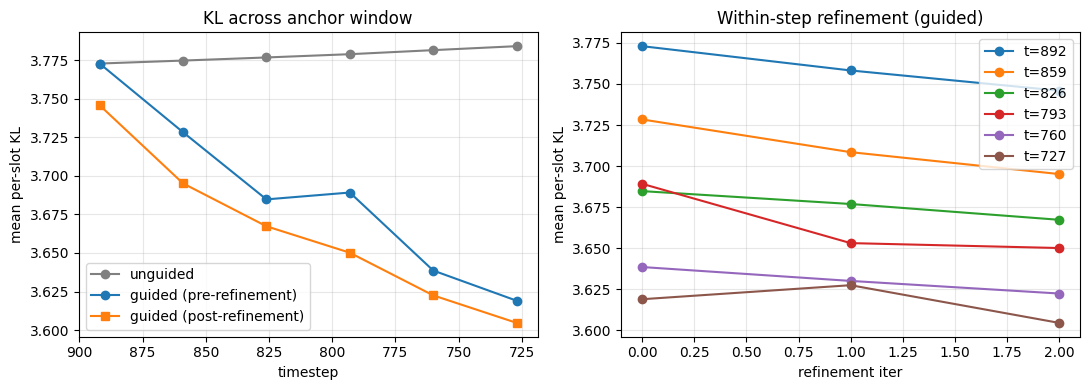

In [ ]:
# 1. KL trace comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
b_t = [r['t'] for r in baseline['trace']]
b_k = [r['kl_pre'] for r in baseline['trace']]
g_t = [r['t'] for r in guided['trace']]
g_k_pre = [r['kl_pre'] for r in guided['trace']]
g_k_post = [r['kl_post'] for r in guided['trace']]

axes[0].plot(b_t, b_k, 'o-', label='unguided', color='gray')
axes[0].plot(g_t, g_k_pre, 'o-', label='guided (pre-refinement)', color='C0')
axes[0].plot(g_t, g_k_post, 's-', label='guided (post-refinement)', color='C1')
axes[0].set_xlabel('timestep'); axes[0].set_ylabel('mean per-slot KL')
axes[0].set_title('KL across anchor window'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].invert_xaxis()  # higher t is earlier in denoising

# 2. Per-iter KL within each guided anchor timestep
for row in guided['trace']:
    axes[1].plot(range(len(row['kl_iters'])), row['kl_iters'], 'o-', label=f't={row["t"]}')
axes[1].set_xlabel('refinement iter'); axes[1].set_ylabel('mean per-slot KL')
axes[1].set_title('Within-step refinement (guided)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/kl_traces.png', dpi=100, bbox_inches='tight')
plt.show()

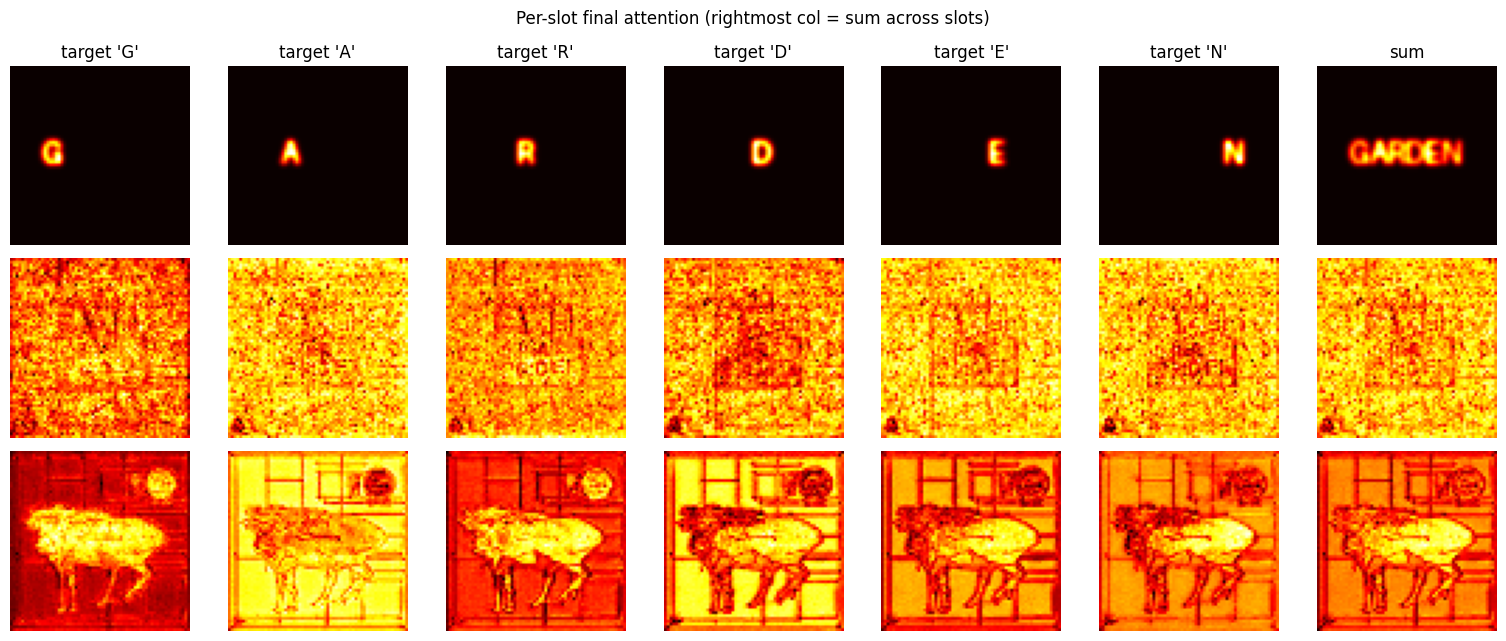

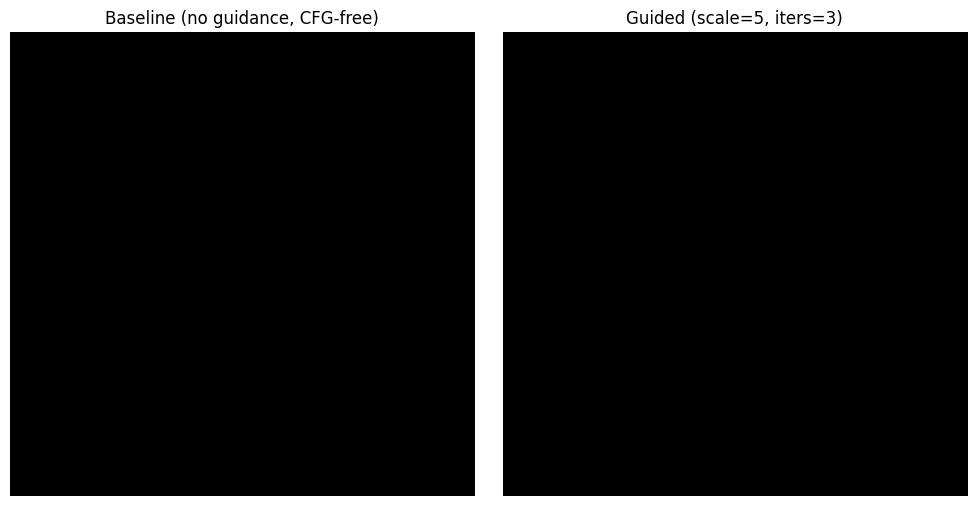

Saved all artifacts.


In [ ]:
# 2. Per-slot final attention: target | baseline | guided
fig, axes = plt.subplots(3, N_SLOTS + 1, figsize=(2.2*(N_SLOTS+1), 6.5))
for i, ch in enumerate(CONFIG['target_string']):
    axes[0, i].imshow(A_star_slots[i].cpu().numpy(), cmap='hot'); axes[0, i].axis('off')
    axes[0, i].set_title(f"target '{ch}'")
    axes[1, i].imshow(baseline['A_final'][i], cmap='hot'); axes[1, i].axis('off')
    axes[2, i].imshow(guided['A_final'][i], cmap='hot'); axes[2, i].axis('off')
axes[0, -1].imshow(A_star_slots.sum(dim=0).cpu().numpy(), cmap='hot'); axes[0, -1].axis('off'); axes[0, -1].set_title('sum')
axes[1, -1].imshow(baseline['A_final'].sum(axis=0), cmap='hot'); axes[1, -1].axis('off')
axes[2, -1].imshow(guided['A_final'].sum(axis=0), cmap='hot'); axes[2, -1].axis('off')
axes[1, 0].set_ylabel('baseline', fontsize=11)
axes[2, 0].set_ylabel('guided', fontsize=11)
plt.suptitle('Per-slot final attention (rightmost col = sum across slots)')
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/attention_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# 3. Final images side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(baseline['image']); axes[0].set_title('Baseline (no guidance, CFG-free)'); axes[0].axis('off')
axes[1].imshow(guided['image']); axes[1].set_title(f'Guided (scale={CONFIG["guidance_scale"]}, iters={CONFIG["n_refinement_iters"]})'); axes[1].axis('off')
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/images.png', dpi=100, bbox_inches='tight')
plt.show()

Image.fromarray(baseline['image']).save(f'{LOG_DIR}/baseline.png')
Image.fromarray(guided['image']).save(f'{LOG_DIR}/guided.png')
np.savez(f'{LOG_DIR}/attn_finals.npz',
         target=A_star_slots.cpu().numpy(),
         baseline=baseline['A_final'],
         guided=guided['A_final'])
print('Saved all artifacts.')

Re-decoding baseline...
Re-decoding guided...


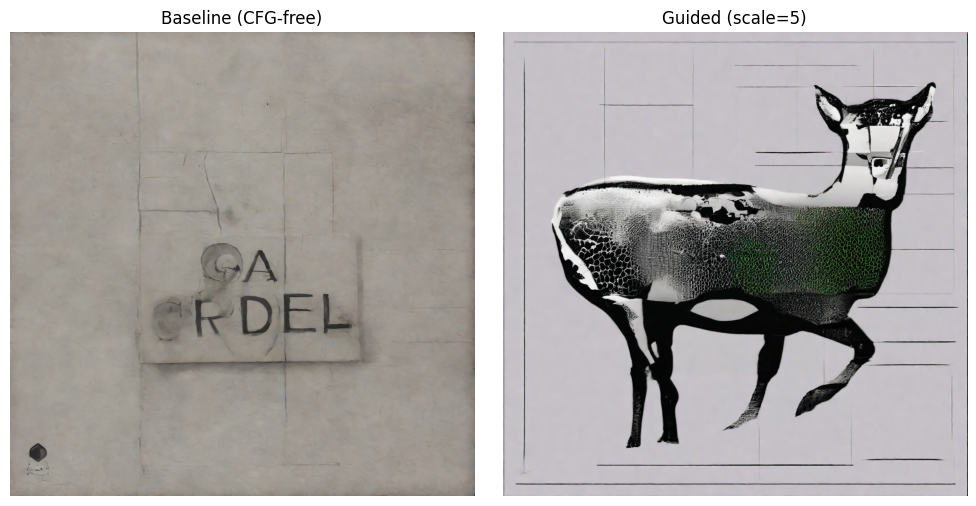

In [ ]:
def run_and_decode_v2(guided):
    gen = torch.Generator(device=device).manual_seed(CONFIG['seed'])
    latents_init = torch.randn((1, 4, CONFIG['latent_size'], CONFIG['latent_size']),
                                generator=gen, device=device, dtype=dtype)
    latents_final, trace = denoising_loop(
        pipe, latents_init,
        prompt_embeds.to(dtype), pooled.to(dtype), TIME_IDS,
        CAPTURE_PROCS, TOKEN_INDICES_PER_SLOT, A_star_slots,
        CONFIG['attn_resolution'], CONFIG['inference_steps'],
        CONFIG['anchor_window'], CONFIG['guidance_scale'],
        CONFIG['n_refinement_iters'],
        guided=guided,
    )
    pipe.vae.to(torch.float32)
    with torch.no_grad():
        img_latents = latents_final.to(torch.float32) / pipe.vae.config.scaling_factor
        img = pipe.vae.decode(img_latents).sample
        img = ((img/2 + 0.5).clamp(0, 1)[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    pipe.vae.to(dtype)
    return img

print('Re-decoding baseline...')
img_b = run_and_decode_v2(guided=False)
print('Re-decoding guided...')
img_g = run_and_decode_v2(guided=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_b); axes[0].set_title('Baseline (CFG-free)'); axes[0].axis('off')
axes[1].imshow(img_g); axes[1].set_title(f'Guided (scale={CONFIG["guidance_scale"]})'); axes[1].axis('off')
plt.tight_layout(); plt.savefig(f'{LOG_DIR}/images_v2.png', dpi=100, bbox_inches='tight'); plt.show()

Image.fromarray(img_b).save(f'{LOG_DIR}/baseline_v2.png')
Image.fromarray(img_g).save(f'{LOG_DIR}/guided_v2.png')


## Summary

Look at `/content/drive/MyDrive/mmai_sbte_phase2/`:

- `kl_traces.png` (left panel): if the orange post-refinement curve is below the blue pre-refinement curve, gradient on `x_t` is doing real work at each anchor timestep. If post-refinement KL at later anchor timesteps is also below baseline at the same `t`, the corrections are sticking through subsequent forwards.
- `kl_traces.png` (right panel): each line should be monotone-decreasing within a step. If it bounces or plateaus instantly, lower `guidance_scale` or raise `n_refinement_iters`.
- `attention_comparison.png`: target row vs. baseline row vs. guided row. Look at the `sum` column especially — that's where 'GARDEN-shape' would show up.
- `images.png`: both will look muted (no CFG). The right one may have visible structure where the left one is empty — that's the qualitative win.

### What to write up regardless of outcome
- **If sanity passes but full inference doesn't help:** corrections at one timestep don't survive the next forward. Worth reporting as 'gradient guidance is locally effective but globally washed out'.
- **If sanity fails:** raw fp16 backward through SDXL is broken for this objective. The result is 'inference-time guidance via per-slot KL needs precision interventions' — still a result, motivating an fp32-forward variant.
- **If both work:** you have an Attend-and-Excite-style result with a richer (spatial-shape) loss. Compare against Phase 1 LoRA in a follow-up notebook.